In [24]:
!pip install tensorflow scikit-learn pandas matplotlib scipy tqdm --quiet
!pip install lime shap scikit-image --quiet
print("✅ Librerías instaladas.")

✅ Librerías instaladas.


In [25]:
import os, gc, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.ndimage import zoom
from tqdm.auto import tqdm
from collections import Counter
from itertools import product
from math import comb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

FONTSCALE = 1.5
FS_TITLE = 13 * FONTSCALE; FS_LABEL = 11 * FONTSCALE
FS_TICK = 10 * FONTSCALE; FS_STATS = 9 * FONTSCALE
c_line = "#1a5276"

OUT_DIR = "/workspace/Process/Images"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("/workspace/Process/metrics", exist_ok=True)

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]
VARIABLES_PAPER = {
    r"$T^{(0)}$":        0,
    r"$\tilde{J}_2$":    1,
    r"$\tilde{K}_{DM}$": 7,
}
GAMMA = 10.0
TARGET_H = TARGET_W = 224

print(f"TF: {tf.__version__} | GPUs: {len(gpus)}")

TF: 2.21.0 | GPUs: 1


In [26]:
DATASET_PATH = "/workspace/Preprocess/latent_space_outputs/dataset_final_estructuras.npz"

data = np.load(DATASET_PATH, allow_pickle=True)
X = np.copy(data['img']).astype(np.float32)
y = np.copy(data['params']).astype(np.float32)
label_all = np.array([str(s) for s in data['label_names']])

idx_all = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_tr, idx_te = train_test_split(
    X, y, idx_all, test_size=0.15, random_state=SEED)
label_test = label_all[idx_te]

scaler = MinMaxScaler().fit(
    train_test_split(y_train, test_size=0.1765, random_state=SEED)[0])
y_test_scaled = scaler.transform(y_test)

structures = ["helical", "Others", "Bimerones", "Skyrmiones", "Ising"]
structures = [s for s in structures if (label_test == s).sum() > 0]

structure_colors = {
    "helical": "#d62728", "Others": "#ff7f0e", "Bimerones": "#9467bd",
    "Skyrmiones": "#2ca02c", "Ising": "#1f77b4",
}
structure_labels = {
    "helical": "Helical phase", "Others": "Others", "Bimerones": "Bimerons",
    "Skyrmiones": "Skyrmions", "Ising": "Ising phase",
}
print(f"Test: {X_test.shape[0]:,} | estructuras: {structures}")

Test: 24,922 | estructuras: ['helical', 'Others', 'Bimerones', 'Skyrmiones', 'Ising']


In [27]:
BASE = "/workspace/Models/Inverse/ModelWeights"
MODEL_PATH = f"{BASE}/modelo_xception_aug_scratch_noweights_estructuras.keras"

class PhysicalAugmentation(tf.keras.layers.Layer):
    def call(self, x, training=None): return x
    def get_config(self): return super().get_config()

model = tf.keras.models.load_model(
    MODEL_PATH, compile=False,
    custom_objects={"PhysicalAugmentation": PhysicalAugmentation})
print(f"✅ Modelo cargado | input: {model.input_shape}")

xception_backbone = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'xception' in layer.name.lower():
        xception_backbone = layer; break
if xception_backbone is None:
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            xception_backbone = layer; break
print(f"Backbone: {xception_backbone.name}")

✅ Modelo cargado | input: (None, 39, 39, 1)
Backbone: xception


In [28]:
LAYER_NAMES = [
    "block1_conv2", "block3_sepconv2", "block4_sepconv2", "block6_sepconv2",
    "block8_sepconv2", "block10_sepconv2", "block12_sepconv2", "block13_sepconv2",
]
avail = set(l.name for l in xception_backbone.layers)
LAYER_NAMES = [ln for ln in LAYER_NAMES if ln in avail]
print("Capas usadas:", LAYER_NAMES)

def build_grad_model(layer_name):
    conv_feat = xception_backbone.get_layer(layer_name).output
    x = xception_backbone.output
    head_started = False
    for layer in model.layers:
        if layer is xception_backbone:
            head_started = True; continue
        if head_started:
            x = layer(x)
    return tf.keras.models.Model(inputs=xception_backbone.input, outputs=[conv_feat, x])

print("Construyendo grad_models...")
grad_models = {ln: build_grad_model(ln) for ln in LAYER_NAMES}
print(f"✅ {len(grad_models)} grad_models listos")

def preprocess_to_224(img_39):
    t = tf.constant(img_39[None, ...], dtype=tf.float32)
    t = tf.image.resize(t, [224, 224])
    t = tf.concat([t, t, t], axis=-1)
    return t

def compute_ram_cnn(img_224_tensor, gm, y_scaled_val, var_idx, gamma=GAMMA):
    theta_true = tf.constant([[float(y_scaled_val[var_idx])]], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = gm(img_224_tensor, training=False)
        tape.watch(conv_out)
        theta_hat = preds[:, var_idx:var_idx+1]
        objective = tf.exp(-gamma * tf.square(theta_true - tf.cast(theta_hat, tf.float32)))
    grads = tape.gradient(objective, conv_out)
    if grads is None:
        return np.zeros((TARGET_H, TARGET_W), dtype=np.float32)
    pooled  = tf.reduce_mean(tf.cast(grads, tf.float32), axis=(0, 1, 2)).numpy()
    conv_np = tf.cast(conv_out, tf.float32).numpy()[0]
    for k in range(pooled.shape[-1]):
        conv_np[:, :, k] *= pooled[k]
    hm = np.maximum(np.mean(conv_np, axis=-1), 0).astype(np.float32)
    h, w = hm.shape
    return zoom(hm, (TARGET_H / h, TARGET_W / w))

def make_circular_mask(size=224, margin=0.06):
    cy = cx = size // 2
    r = (size // 2) * (1 - margin)
    Y, X_ = np.ogrid[:size, :size]
    return ((X_ - cx)**2 + (Y - cy)**2) <= r**2

def mask_ram(heatmap, mask):
    h = heatmap.copy(); h[~mask] = 0.0; return h

def concentration_score(heatmap, mask):
    return (heatmap * mask).sum() / (heatmap.sum() + 1e-10)

circ_mask = make_circular_mask(224, margin=0.06)
print("✅ Funciones RAM listas")

Capas usadas: ['block1_conv2', 'block3_sepconv2', 'block4_sepconv2', 'block6_sepconv2', 'block8_sepconv2', 'block10_sepconv2', 'block12_sepconv2', 'block13_sepconv2']
Construyendo grad_models...
✅ 8 grad_models listos
✅ Funciones RAM listas


In [29]:
print("Seleccionando mejor representante por estructura...")
best_rep = {}
for s in structures:
    idx_s = np.where(label_test == s)[0]
    mean_p = y_test[idx_s].mean(axis=0)
    top10 = idx_s[np.argsort(np.linalg.norm(y_test[idx_s] - mean_p, axis=1))[:10]]
    best_score, best_idx = -1, top10[0]
    for cand in top10:
        img_arr = preprocess_to_224(X_test[cand]); y_sc = y_test_scaled[cand]
        scores = []
        for ln in LAYER_NAMES:
            for vn, vi in VARIABLES_PAPER.items():
                r = compute_ram_cnn(img_arr, grad_models[ln], y_sc, vi)
                scores.append(concentration_score(mask_ram(r, circ_mask), circ_mask))
        ms = np.mean(scores)
        if ms > best_score:
            best_score, best_idx = ms, cand
    best_rep[s] = best_idx
    print(f"  {s:<12} → idx={best_idx} | score={best_score:.3f}")

Seleccionando mejor representante por estructura...
  helical      → idx=669 | score=1.001
  Others       → idx=19970 | score=1.000
  Bimerones    → idx=18913 | score=1.004
  Skyrmiones   → idx=11944 | score=3.463
  Ising        → idx=12589 | score=1.004


In [30]:
print("Calculando RAMs del mejor representante...")
rams_best = {}
for s, sidx in best_rep.items():
    img_arr = preprocess_to_224(X_test[sidx]); y_sc = y_test_scaled[sidx]
    rams_best[s] = {"idx": sidx, "img": X_test[sidx][:, :, 0],
                    "y_val": y_test[sidx], "rams": {}}
    for ln in LAYER_NAMES:
        rams_best[s]["rams"][ln] = {}
        for vn, vi in VARIABLES_PAPER.items():
            r = compute_ram_cnn(img_arr, grad_models[ln], y_sc, vi)
            rams_best[s]["rams"][ln][vn] = mask_ram(r, circ_mask)
    print(f"  ✓ {s}")
print("✅ rams_best listo")

Calculando RAMs del mejor representante...
  ✓ helical
  ✓ Others
  ✓ Bimerones
  ✓ Skyrmiones
  ✓ Ising
✅ rams_best listo


In [31]:
from skimage.segmentation import slic as slic_fn
COMPACTNESS = 0.1
N_SEGMENTS = 100   # coincide con el ancho de dominio (~4.9 px) por criterio espectral
print(f"SLIC: N_SEGMENTS={N_SEGMENTS}, compactness={COMPACTNESS}")

SLIC: N_SEGMENTS=100, compactness=0.1


In [32]:
def predict_fn_batch(imgs_39, var_idx):
    arr = np.asarray(imgs_39, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[..., None]
    if arr.shape[-1] == 3:
        arr = arr[..., :1]
    preds = model.predict(arr, verbose=0)
    return preds[:, var_idx]

def get_baseline(img):
    return float(img.mean())

print("✅ predict_fn listo")

✅ predict_fn listo


Periodo helical: 9.8 px → ancho de dominio ≈ 4.9 px
n_segments=  20 → diámetro equivalente = 15.27 ± 3.89 px
n_segments=  40 → diámetro equivalente = 9.10 ± 2.60 px
n_segments=  60 → diámetro equivalente = 6.47 ± 1.59 px
n_segments= 100 → diámetro equivalente = 4.94 ± 1.22 px
n_segments= 150 → diámetro equivalente = 3.60 ± 0.78 px


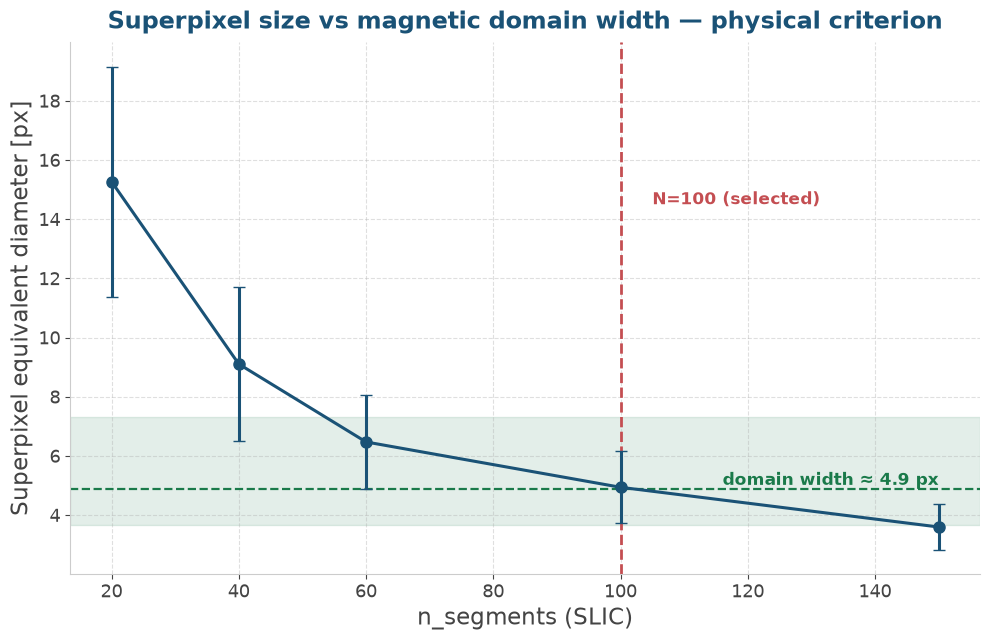

✅ slic_physical_criterion.pdf


In [33]:
from skimage.segmentation import slic as slic_fn  # por si no está aún

def periodo_dominante(img):
    h, w = img.shape
    win = np.outer(np.hanning(h), np.hanning(w))
    f = np.fft.fftshift(np.abs(np.fft.fft2((img - img.mean()) * win))**2)
    cy, cx = h // 2, w // 2
    Y, X_ = np.ogrid[:h, :w]
    r = np.sqrt((X_ - cx)**2 + (Y - cy)**2).astype(int)
    radial = np.bincount(r.ravel(), f.ravel()) / (np.bincount(r.ravel()) + 1e-9)
    radial[:2] = 0
    kmax = min(h, w) // 2
    k_peak = radial[:kmax].argmax()
    return min(h, w) / k_peak if k_peak > 0 else np.inf

per_hel = np.median([periodo_dominante(X_test[i][:, :, 0])
                     for i in np.where(label_test == "helical")[0][:150]])
stripe_width = per_hel / 2
print(f"Periodo helical: {per_hel:.1f} px → ancho de dominio ≈ {stripe_width:.1f} px")

N_OPTIONS = [20, 40, 60, 100, 150]
diam_eq = {}
for nseg in N_OPTIONS:
    diams = []
    for s, sidx in best_rep.items():
        img = X_test[sidx][:, :, 0]
        segs = slic_fn(img, n_segments=nseg, compactness=COMPACTNESS,
                       channel_axis=None, start_label=0)
        areas = np.bincount(segs.ravel())
        diams.extend(2 * np.sqrt(areas / np.pi))
    diam_eq[nseg] = (np.mean(diams), np.std(diams))
    print(f"n_segments={nseg:>4} → diámetro equivalente = {np.mean(diams):.2f} ± {np.std(diams):.2f} px")

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor="white")
ns = list(diam_eq.keys()); mus = [diam_eq[n][0] for n in ns]; sds = [diam_eq[n][1] for n in ns]
ax.errorbar(ns, mus, yerr=sds, marker="o", markersize=8, linewidth=2.2, capsize=4,
            color="#1a5276", zorder=3)
ax.axhspan(stripe_width*0.75, stripe_width*1.5, color="#1a7a4a", alpha=0.12, zorder=1)
ax.axhline(stripe_width, color="#1a7a4a", linewidth=1.6, linestyle="--", zorder=2)
ax.text(ns[-1], stripe_width*1.03, f"domain width ≈ {stripe_width:.1f} px",
        fontsize=FS_STATS*0.9, color="#1a7a4a", ha="right", fontweight="bold")
ax.axvline(N_SEGMENTS, color="#C44E52", linewidth=2.0, linestyle="--", zorder=2)
ax.text(N_SEGMENTS*1.05, max(mus)*0.95, f"N={N_SEGMENTS} (selected)",
        fontsize=FS_STATS*0.9, color="#C44E52", fontweight="bold")
ax.set_xlabel("n_segments (SLIC)", fontsize=FS_LABEL, color="#444444")
ax.set_ylabel("Superpixel equivalent diameter [px]", fontsize=FS_LABEL, color="#444444")
ax.set_title("Superpixel size vs magnetic domain width — physical criterion",
             fontsize=FS_TITLE*0.9, fontweight="bold", color=c_line, pad=10)
ax.tick_params(labelsize=FS_TICK*0.85, colors="#444444")
ax.grid(linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/slic_physical_criterion.pdf", bbox_inches="tight", facecolor="white")
plt.show()   



print("✅ slic_physical_criterion.pdf")

In [34]:
from lime import lime_image

def segmentation_fn(image_rgb):
    return slic_fn(image_rgb[..., 0], n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                   channel_axis=None, start_label=0)

lime_maps = {}
explainer = lime_image.LimeImageExplainer(random_state=42)
for s, sidx in best_rep.items():
    print(f"▶ LIME {s}")
    img = X_test[sidx][:, :, 0].astype(np.float64)
    img_rgb = np.stack([img]*3, axis=-1)
    lime_maps[s] = {}
    for vn, vi in VARIABLES_PAPER.items():
        exp = explainer.explain_instance(
            img_rgb, classifier_fn=lambda x, _vi=vi: predict_fn_batch(x, _vi).reshape(-1, 1),
            labels=(0,), hide_color=get_baseline(img),
            num_samples=1000, segmentation_fn=segmentation_fn, batch_size=128)
        segs = exp.segments; weights = dict(exp.local_exp[0])
        m = np.zeros_like(img, dtype=np.float32)
        for seg_id, w in weights.items():
            m[segs == seg_id] = abs(w)
        lime_maps[s][vn] = m
print("✅ LIME completo")

▶ LIME helical


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

▶ LIME Others


...

▶ LIME Ising


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

✅ LIME completo


In [35]:
import shap
shap_maps = {}
for s, sidx in best_rep.items():
    print(f"▶ SHAP {s}")
    img = X_test[sidx][:, :, 0].astype(np.float32)
    segs = slic_fn(img, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                   channel_axis=None, start_label=0)
    n_segs = segs.max() + 1; baseline = get_baseline(img)
    def mask_to_images(z_batch):
        out = np.repeat(img[None, ...], z_batch.shape[0], axis=0).copy()
        for i, z in enumerate(z_batch):
            off = np.isin(segs, np.where(z == 0)[0]); out[i][off] = baseline
        return out
    shap_maps[s] = {}
    for vn, vi in VARIABLES_PAPER.items():
        f = lambda z, _vi=vi: predict_fn_batch(mask_to_images(z), _vi)
        ke = shap.KernelExplainer(f, np.zeros((1, n_segs)))
        sv = np.array(ke.shap_values(np.ones((1, n_segs)), nsamples=1000, silent=True)).reshape(-1)
        m = np.zeros_like(img, dtype=np.float32)
        for seg_id in range(n_segs):
            m[segs == seg_id] = abs(sv[seg_id])
        shap_maps[s][vn] = m
print("✅ SHAP completo")

▶ SHAP helical
▶ SHAP Others
▶ SHAP Bimerones
▶ SHAP Skyrmiones
▶ SHAP Ising
✅ SHAP completo


In [36]:
Q_BANDS = 7   # 2^7 = 128 coaliciones exactas

def build_radial_bands(shape=(39, 39), Q=Q_BANDS):
    h, w = shape; cy, cx = h // 2, w // 2
    Y, X_ = np.ogrid[:h, :w]
    R = np.sqrt((X_ - cx)**2 + (Y - cy)**2)
    edges = np.linspace(0, R.max(), Q + 1)
    band_id = np.zeros((h, w), dtype=int)
    for q in range(Q):
        band_id[(R >= edges[q]) & (R < edges[q+1])] = q
    band_id[R >= edges[-1]] = Q - 1
    return band_id

BAND_ID = build_radial_bands((39, 39), Q_BANDS)

def reconstruct_from_coalition(img, z, band_id):
    F = np.fft.fftshift(np.fft.fft2(img))
    mask = np.zeros_like(img, dtype=bool)
    for q in range(len(z)):
        if z[q] == 1:
            mask |= (band_id == q)
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * mask))).astype(np.float32)

def shapley_kernel_weight(M, s):
    if s == 0 or s == M:
        return 1e6
    return (M - 1) / (comb(M, s) * s * (M - s))

# Versión con batch (para calcular los mapas — rápida)
def sf_kernelshap(img, var_idx, band_id, Q=Q_BANDS):
    Z = np.array(list(product([0, 1], repeat=Q)), dtype=np.float32)
    recs = np.stack([reconstruct_from_coalition(img, z, band_id) for z in Z])
    fz = predict_fn_batch(recs, var_idx)
    W = np.array([shapley_kernel_weight(Q, int(z.sum())) for z in Z])
    A = np.hstack([np.ones((len(Z), 1)), Z]); Wd = np.diag(W)
    coef = np.linalg.lstsq(Wd @ A, Wd @ fz, rcond=None)[0]
    phi = coef[1:]
    sal = np.zeros_like(img, dtype=np.float32)
    F = np.fft.fftshift(np.fft.fft2(img))
    for q in range(Q):
        band_rec = np.real(np.fft.ifft2(np.fft.ifftshift(F * (band_id == q))))
        sal += abs(phi[q]) * np.abs(band_rec)
    return phi, (sal / (sal.max() + 1e-10)).astype(np.float32)

# Versión secuencial (solo para timing justo — una coalición a la vez)
def sf_kernelshap_sequential(img, var_idx, band_id, Q=Q_BANDS):
    Z = np.array(list(product([0, 1], repeat=Q)), dtype=np.float32)
    fz = np.array([
        predict_fn_batch(reconstruct_from_coalition(img, z, band_id)[None, ...], var_idx)[0]
        for z in Z
    ])
    W = np.array([shapley_kernel_weight(Q, int(z.sum())) for z in Z])
    A = np.hstack([np.ones((len(Z), 1)), Z]); Wd = np.diag(W)
    coef = np.linalg.lstsq(Wd @ A, Wd @ fz, rcond=None)[0]
    return coef[1:]

# control de sanidad FFT
_img0 = X_test[best_rep[structures[0]]][:, :, 0].astype(np.float32)
_test = reconstruct_from_coalition(_img0, np.ones(Q_BANDS), BAND_ID)
print(f"Control FFT (debe ser ~0): {np.abs(_test - _img0).max():.2e}")

# calcular mapas SF-SHAP (con la versión batch, rápida)
sfshap_maps, sfshap_phi = {}, {}
for s, sidx in best_rep.items():
    print(f"▶ SF-KernelSHAP {s}")
    img = X_test[sidx][:, :, 0].astype(np.float32)
    sfshap_maps[s], sfshap_phi[s] = {}, {}
    for vn, vi in VARIABLES_PAPER.items():
        phi, sal = sf_kernelshap(img, vi, BAND_ID)
        sfshap_maps[s][vn] = sal; sfshap_phi[s][vn] = phi
print("✅ SF-KernelSHAP completo")

Control FFT (debe ser ~0): 1.79e-07
▶ SF-KernelSHAP helical
▶ SF-KernelSHAP Others
▶ SF-KernelSHAP Bimerones
▶ SF-KernelSHAP Skyrmiones
▶ SF-KernelSHAP Ising
✅ SF-KernelSHAP completo


In [37]:
ram_maps = {}
for s in structures:
    ram_maps[s] = {}
    for vn in VARIABLES_PAPER:
        acc = np.zeros((TARGET_H, TARGET_W), dtype=np.float32)
        for ln in LAYER_NAMES:
            acc += rams_best[s]["rams"][ln][vn]
        ram_maps[s][vn] = zoom(acc, (39/TARGET_H, 39/TARGET_W))
print("✅ RAM maps a 39×39")

✅ RAM maps a 39×39


Deletion:   0%|          | 0/5 [00:00<?, ?it/s]


AUC de deleción (mayor = mejor localización):
  $T^{(0)}$ | RAM     : AUC=0.0331
  $T^{(0)}$ | LIME    : AUC=0.0474
  $T^{(0)}$ | SHAP    : AUC=0.0435
  $T^{(0)}$ | SF-SHAP : AUC=0.0534
  $T^{(0)}$ | Random  : AUC=0.1096
  $\tilde{J}_2$ | RAM     : AUC=0.0372
  $\tilde{J}_2$ | LIME    : AUC=0.0419
  $\tilde{J}_2$ | SHAP    : AUC=0.0185
  $\tilde{J}_2$ | SF-SHAP : AUC=0.0550
  $\tilde{J}_2$ | Random  : AUC=0.0264
  $\tilde{K}_{DM}$ | RAM     : AUC=0.0671
  $\tilde{K}_{DM}$ | LIME    : AUC=0.1078
  $\tilde{K}_{DM}$ | SHAP    : AUC=0.0772
  $\tilde{K}_{DM}$ | SF-SHAP : AUC=0.1226
  $\tilde{K}_{DM}$ | Random  : AUC=0.0444


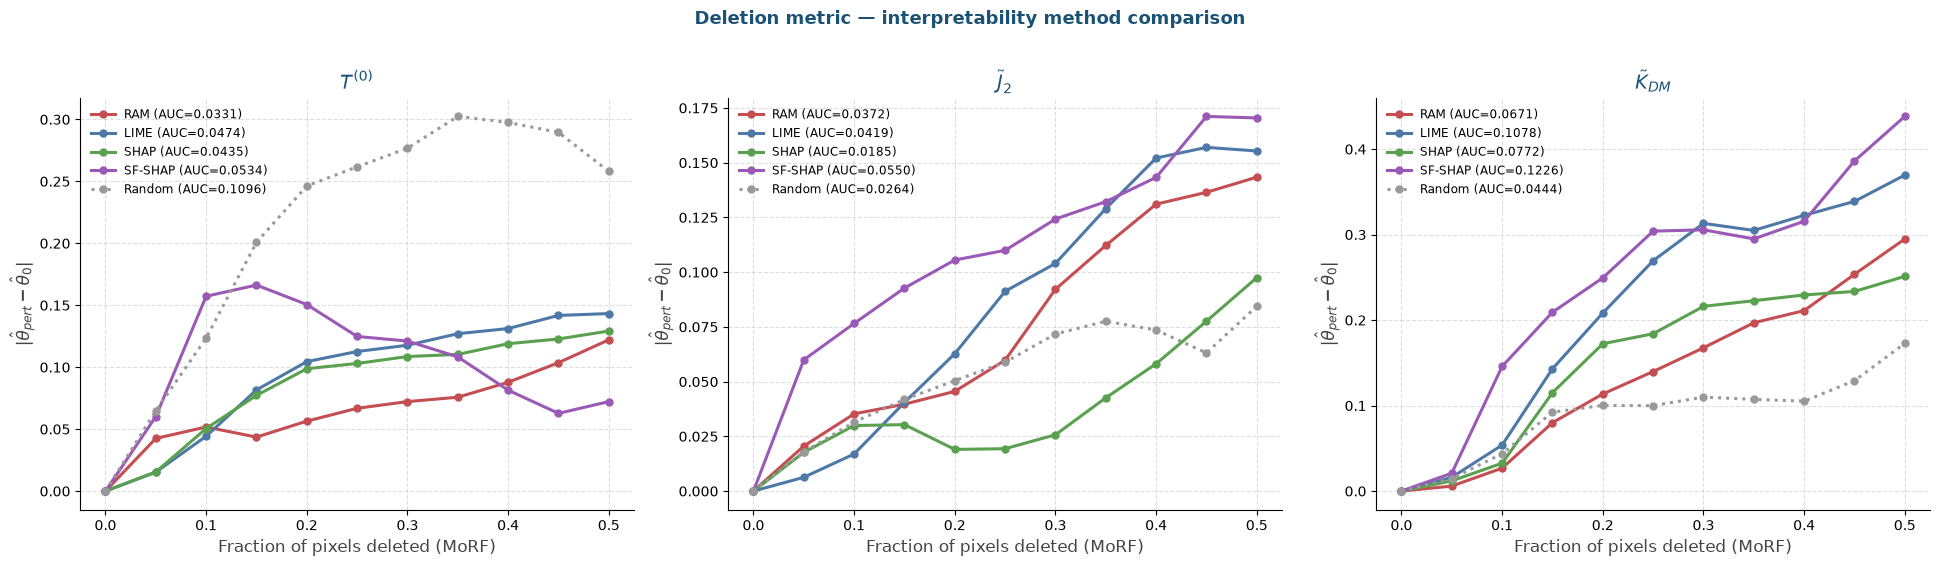

✅ deletion_comparison.pdf


In [38]:
DELETION_FRACTIONS = np.linspace(0, 0.5, 11)

def deletion_curve(img, relevance_map, var_idx, baseline):
    flat_order = np.argsort(relevance_map.flatten())[::-1]
    pred0 = predict_fn_batch(img[None, ...], var_idx)[0]
    n_pix = img.size; devs = []
    for frac in DELETION_FRACTIONS:
        k = int(frac * n_pix)
        img_p = img.flatten().copy(); img_p[flat_order[:k]] = baseline
        pred = predict_fn_batch(img_p.reshape(img.shape)[None, ...], var_idx)[0]
        devs.append(abs(pred - pred0))
    return np.array(devs)

methods = {"RAM": ram_maps, "LIME": lime_maps, "SHAP": shap_maps, "SF-SHAP": sfshap_maps}
method_colors = {"RAM": "#C44E52", "LIME": "#4e79a7", "SHAP": "#59a14f",
                 "SF-SHAP": "#9b59b6", "Random": "#999999"}
rng = np.random.default_rng(SEED)

results_del = {vn: {m: [] for m in list(methods) + ["Random"]} for vn in VARIABLES_PAPER}
for s, sidx in tqdm(best_rep.items(), desc="Deletion"):
    img = X_test[sidx][:, :, 0].astype(np.float32); baseline = get_baseline(img)
    for vn, vi in VARIABLES_PAPER.items():
        for mname, mmaps in methods.items():
            results_del[vn][mname].append(deletion_curve(img, mmaps[s][vn], vi, baseline))
        results_del[vn]["Random"].append(deletion_curve(img, rng.random(img.shape), vi, baseline))

fig, axes = plt.subplots(1, len(VARIABLES_PAPER), figsize=(6.5*len(VARIABLES_PAPER), 5.5),
                         facecolor="white")
print("\nAUC de deleción (mayor = mejor localización):")
for ci, vn in enumerate(VARIABLES_PAPER):
    ax = axes[ci]
    for mname in ["RAM", "LIME", "SHAP", "SF-SHAP", "Random"]:
        mean_curve = np.mean(results_del[vn][mname], axis=0)
        auc = np.trapz(mean_curve, DELETION_FRACTIONS)
        ls = ":" if mname == "Random" else "-"
        ax.plot(DELETION_FRACTIONS, mean_curve, marker="o", markersize=5, linewidth=2.2,
                linestyle=ls, label=f"{mname} (AUC={auc:.4f})",
                color=method_colors[mname], zorder=3)
        print(f"  {vn} | {mname:8s}: AUC={auc:.4f}")
    ax.set_xlabel("Fraction of pixels deleted (MoRF)", fontsize=12, color="#444")
    ax.set_ylabel(r"$|\hat\theta_{pert}-\hat\theta_0|$", fontsize=12, color="#444")
    ax.set_title(vn, fontsize=14, fontweight="bold", color=c_line)
    ax.grid(linestyle="--", alpha=0.4); ax.legend(fontsize=8.5, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Deletion metric — interpretability method comparison",
             fontsize=13, fontweight="bold", color=c_line, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/deletion_comparison.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("✅ deletion_comparison.pdf")

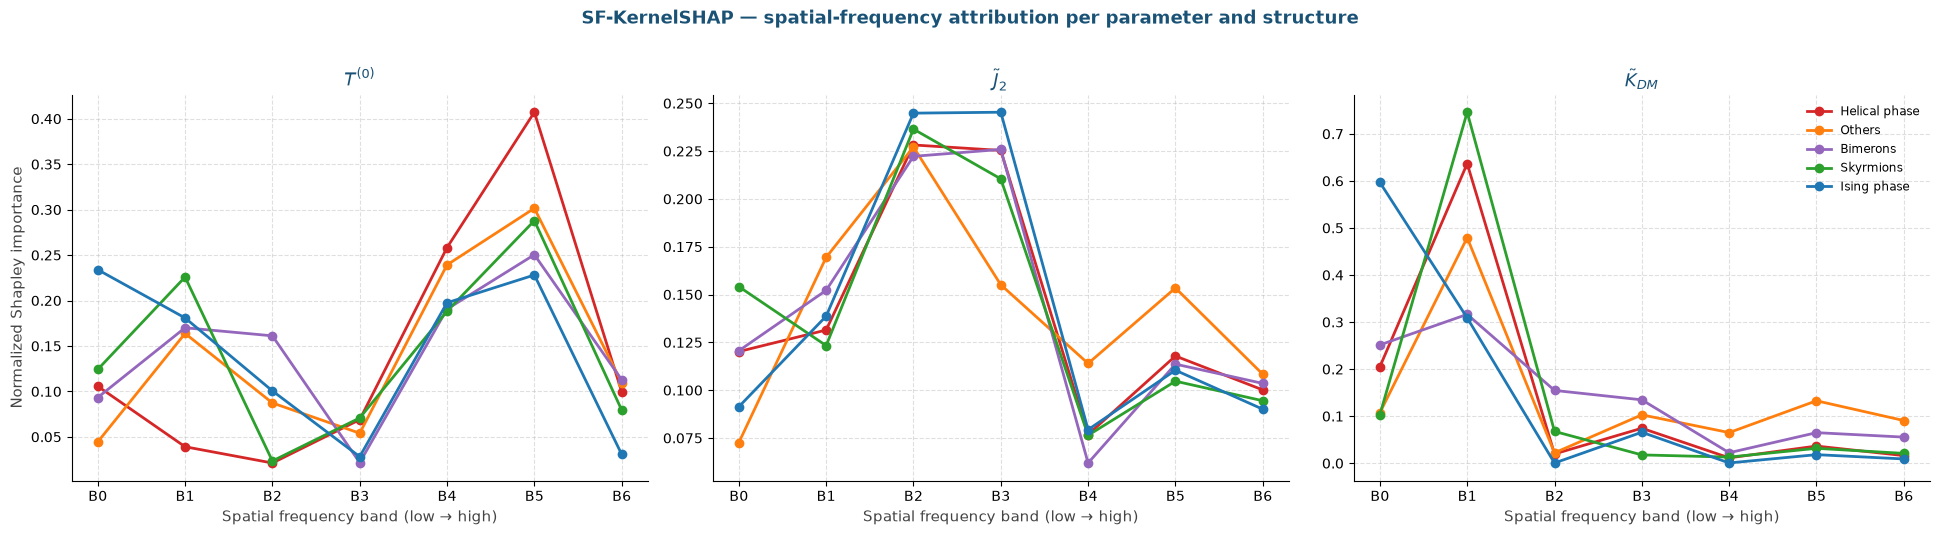

✅ sf_kernelshap_frequency_bands.pdf


In [39]:
freq_labels = [f"B{q}" for q in range(Q_BANDS)]
fig, axes = plt.subplots(1, len(VARIABLES_PAPER), figsize=(6.5*len(VARIABLES_PAPER), 5.2),
                         facecolor="white")
for ci, vn in enumerate(VARIABLES_PAPER):
    ax = axes[ci]
    for s in best_rep:
        phi = np.abs(sfshap_phi[s][vn]); phi = phi / (phi.sum() + 1e-10)
        ax.plot(range(Q_BANDS), phi, marker="o", linewidth=2.0, markersize=6,
                label=structure_labels[s], color=structure_colors[s], zorder=3)
    ax.set_xticks(range(Q_BANDS)); ax.set_xticklabels(freq_labels)
    ax.set_xlabel("Spatial frequency band (low → high)", fontsize=11, color="#444")
    ax.set_ylabel("Normalized Shapley importance" if ci == 0 else "", fontsize=11, color="#444")
    ax.set_title(vn, fontsize=13, fontweight="bold", color=c_line)
    ax.grid(linestyle="--", alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
    if ci == len(VARIABLES_PAPER) - 1:
        ax.legend(fontsize=8.5, frameon=False)
plt.suptitle("SF-KernelSHAP — spatial-frequency attribution per parameter and structure",
             fontsize=13, fontweight="bold", color=c_line, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sf_kernelshap_frequency_bands.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("✅ sf_kernelshap_frequency_bands.pdf")

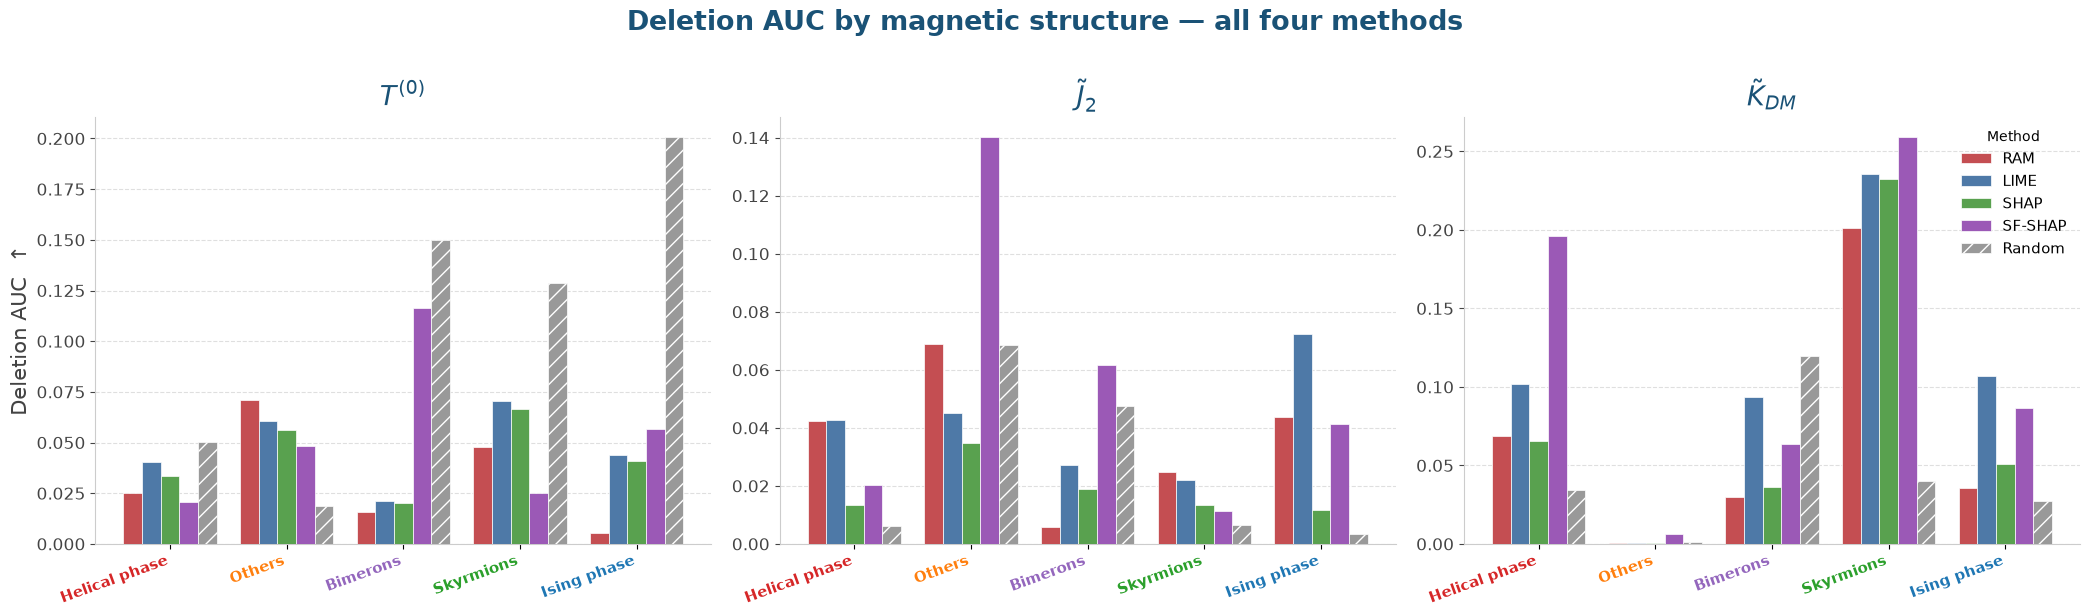

✅ deletion_auc_by_structure.pdf


In [40]:
struct_order = list(best_rep.keys())
methods_all = ["RAM", "LIME", "SHAP", "SF-SHAP", "Random"]
auc_by_struct = {vn: {m: [] for m in methods_all} for vn in VARIABLES_PAPER}
for vn in VARIABLES_PAPER:
    for m in methods_all:
        for k in range(len(struct_order)):
            auc_by_struct[vn][m].append(np.trapz(results_del[vn][m][k], DELETION_FRACTIONS))

n_vars_p = len(VARIABLES_PAPER); x_str = np.arange(len(struct_order)); bar_w = 0.16
fig, axes = plt.subplots(1, n_vars_p, figsize=(7.0*n_vars_p, 6), facecolor="white")
for ci, vn in enumerate(VARIABLES_PAPER):
    ax = axes[ci]
    for m_i, m in enumerate(methods_all):
        offset = (m_i - len(methods_all)/2 + 0.5) * bar_w
        ax.bar(x_str + offset, auc_by_struct[vn][m], width=bar_w, label=m,
               color=method_colors[m], edgecolor="white", linewidth=0.5,
               hatch="//" if m == "Random" else None, zorder=3)
    ax.set_xticks(x_str)
    ax.set_xticklabels([structure_labels[s] for s in struct_order],
                       fontsize=FS_TICK*0.7, rotation=20, ha="right", fontweight="bold")
    for tick, s in zip(ax.get_xticklabels(), struct_order):
        tick.set_color(structure_colors[s])
    ax.set_ylabel("Deletion AUC  ↑" if ci == 0 else "", fontsize=FS_LABEL*0.9, color="#444444")
    ax.set_title(vn, fontsize=FS_TITLE, fontweight="bold", color=c_line, pad=8)
    ax.tick_params(axis="y", labelsize=FS_TICK*0.8, colors="#444444")
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0); ax.set_ylim(bottom=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")
    if ci == n_vars_p - 1:
        ax.legend(fontsize=FS_STATS*0.8, frameon=False, title="Method")
fig.suptitle("Deletion AUC by magnetic structure — all four methods",
             fontsize=FS_TITLE, fontweight="bold", color=c_line, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/deletion_auc_by_structure.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("✅ deletion_auc_by_structure.pdf")

In [41]:
timing = {"RAM": [], "LIME": [], "SHAP": [], "SF-SHAP": []}
model_evals = {"RAM": 1, "LIME": 1000, "SHAP": 1000, "SF-SHAP": 2**Q_BANDS}
LAYER_EVAL = "block8_sepconv2"

for s, sidx in best_rep.items():
    img     = X_test[sidx][:, :, 0].astype(np.float64)
    img_f32 = img.astype(np.float32)
    img_rgb = np.stack([img]*3, axis=-1)
    img_224 = preprocess_to_224(X_test[sidx])
    y_sc    = y_test_scaled[sidx]
    baseline = get_baseline(img_f32)
    segs = slic_fn(img_f32, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                   channel_axis=None, start_label=0)
    n_segs = segs.max() + 1

    for vn, vi in VARIABLES_PAPER.items():
        # RAM
        t0 = time.perf_counter()
        _ = compute_ram_cnn(img_224, grad_models[LAYER_EVAL], y_sc, vi)
        timing["RAM"].append(time.perf_counter() - t0)
        # LIME
        t0 = time.perf_counter()
        _ = explainer.explain_instance(
            img_rgb, classifier_fn=lambda x, _vi=vi: predict_fn_batch(x, _vi).reshape(-1, 1),
            labels=(0,), hide_color=baseline, num_samples=1000,
            segmentation_fn=segmentation_fn, batch_size=128)
        timing["LIME"].append(time.perf_counter() - t0)
        # SHAP
        def mask_to_images(z_batch):
            out = np.repeat(img_f32[None, ...], z_batch.shape[0], axis=0).copy()
            for i, z in enumerate(z_batch):
                off = np.isin(segs, np.where(z == 0)[0]); out[i][off] = baseline
            return out
        t0 = time.perf_counter()
        f = lambda z, _vi=vi: predict_fn_batch(mask_to_images(z), _vi)
        ke = shap.KernelExplainer(f, np.zeros((1, n_segs)))
        _ = ke.shap_values(np.ones((1, n_segs)), nsamples=1000, silent=True)
        timing["SHAP"].append(time.perf_counter() - t0)
        # SF-SHAP (secuencial)
        t0 = time.perf_counter()
        _ = sf_kernelshap_sequential(img_f32, vi, BAND_ID)
        timing["SF-SHAP"].append(time.perf_counter() - t0)

    print(f"  ✓ {s}")

rows = []
lime_mean = np.mean(timing["LIME"])
for m in ["RAM", "SF-SHAP", "SHAP", "LIME"]:
    ts = np.array(timing[m])
    rows.append({"Method": m,
                 "Time/map (s)": f"{ts.mean():.3f} ± {ts.std():.3f}",
                 "Model evals": model_evals[m],
                 "Speedup vs LIME": f"{lime_mean/ts.mean():.0f}×"})
df_time = pd.DataFrame(rows).set_index("Method")
print("\n" + "="*60)
print(df_time.to_string())
df_time.to_csv("/workspace/Process/metrics/interpretability_cost.csv")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  ✓ helical


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  ✓ Skyrmiones


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  ✓ Ising

           Time/map (s)  Model evals Speedup vs LIME
Method                                              
RAM       0.246 ± 0.024            1              6×
SF-SHAP  17.816 ± 0.903          128              0×
SHAP      0.725 ± 0.066         1000              2×
LIME      1.470 ± 0.097         1000              1×


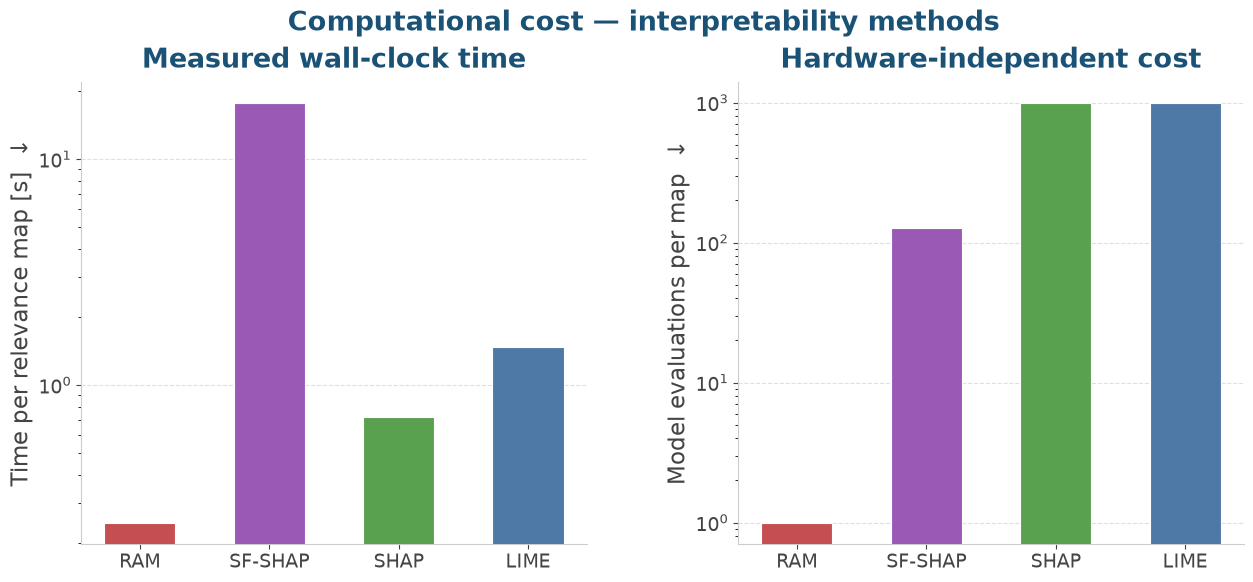

✅ interpretability_cost.pdf


In [42]:
methods_plot = {
    "RAM":     (np.mean(timing["RAM"]),     model_evals["RAM"]),
    "SF-SHAP": (np.mean(timing["SF-SHAP"]), model_evals["SF-SHAP"]),
    "SHAP":    (np.mean(timing["SHAP"]),    model_evals["SHAP"]),
    "LIME":    (np.mean(timing["LIME"]),    model_evals["LIME"]),
}
method_colors_t = {"RAM": "#C44E52", "SF-SHAP": "#9b59b6", "SHAP": "#59a14f", "LIME": "#4e79a7"}
names  = list(methods_plot.keys())
times  = [methods_plot[m][0] for m in names]
evals  = [methods_plot[m][1] for m in names]
colors = [method_colors_t[m] for m in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor="white",
                         gridspec_kw={"wspace": 0.30})
ax = axes[0]
ax.bar(names, times, width=0.55, color=colors, edgecolor="white", linewidth=0.8, zorder=3)
ax.set_yscale("log")
ax.set_ylabel("Time per relevance map [s]  ↓", fontsize=FS_LABEL, color="#444444")
ax.set_title("Measured wall-clock time", fontsize=FS_TITLE, fontweight="bold", color=c_line, pad=10)
ax.tick_params(labelsize=FS_TICK*0.9, colors="#444444")
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")

ax2 = axes[1]
ax2.bar(names, evals, width=0.55, color=colors, edgecolor="white", linewidth=0.8, zorder=3)
ax2.set_yscale("log")
ax2.set_ylabel("Model evaluations per map  ↓", fontsize=FS_LABEL, color="#444444")
ax2.set_title("Hardware-independent cost", fontsize=FS_TITLE, fontweight="bold", color=c_line, pad=10)
ax2.tick_params(labelsize=FS_TICK*0.9, colors="#444444")
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines["left"].set_color("#cccccc"); ax2.spines["bottom"].set_color("#cccccc")

fig.suptitle("Computational cost — interpretability methods",
             fontsize=FS_TITLE, fontweight="bold", color=c_line, y=1.00)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/interpretability_cost.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("✅ interpretability_cost.pdf")